Stock Price Prediction Model

# Aarthic

The name “Aarthic” is derived from the
Sanskrit word “Aarthik” (आर्थिक), which means financial, economic, or related to wealth.

Requirements


In [40]:
!pip install -q yfinance pandas numpy scikit-learn xgboost matplotlib seaborn joblib nbconvert

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [4]:
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)
print("Outputs go to /content/outputs/")

Outputs go to /content/outputs/


Data Collection

In [5]:
import yfinance as yf

In [6]:
COMPANY = "TCS.NS"   # change to INFY.NS, HDFCBANK.NS, RELIANCE.NS etc.
# Here COMPANY is TICKER
START = "2023-01-01"
END = None


In [7]:
df = yf.download(COMPANY, start=START, end=END, progress=False)
df = df.sort_index().ffill().dropna(how='all')
df['Return'] = df['Close'].pct_change()
print("Downloaded rows:", len(df))


/tmp/ipython-input-488793009.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(COMPANY, start=START, end=END, progress=False)


Downloaded rows: 704


In [8]:
df.head()

Price,Close,High,Low,Open,Volume,Return
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,
Date,,,,,,
2023-01-02,2986.108887,2991.053137,2962.074988,2985.696922,709547,NaN
2023-01-03,3031.796143,3039.715795,2971.322234,2977.456555,1245178,0.015300
2023-01-04,3034.817627,3046.445635,3008.769502,3027.538834,1231668,0.000997
2023-01-05,3031.567383,3055.555458,3004.878177,3049.054771,1826057,-0.001071
2023-01-06,2940.421631,3022.823568,2929.846671,3021.404379,2488376,-0.030066


Lets do some EDA (Exploratory Data Anlaysis)

In [9]:
print("Date range:", df.index.min(), "to", df.index.max())
print("\nData info:")
display(df.info())

Date range: 2023-01-02 00:00:00 to 2025-11-07 00:00:00

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 704 entries, 2023-01-02 to 2025-11-07
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   704 non-null    float64
 1   (High, TCS.NS)    704 non-null    float64
 2   (Low, TCS.NS)     704 non-null    float64
 3   (Open, TCS.NS)    704 non-null    float64
 4   (Volume, TCS.NS)  704 non-null    int64  
 5   (Return, )        703 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 38.5 KB


None

In [10]:
print("\nSummary stats:")
display(df[['Open','High','Low','Close','Volume','Return']].describe().T)

print("\nMissing values per column:")
display(df.isna().sum())


Summary stats:


,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Open,TCS.NS,704.0,3.508027e+03,4.064945e+02,2880.257593,3.150713e+03,3.419488e+03,3.848742e+03,4.411415e+03
High,TCS.NS,704.0,3.538248e+03,4.136178e+02,2904.467428,3.175762e+03,3.444616e+03,3.880595e+03,4.427081e+03
Low,TCS.NS,704.0,3.478054e+03,4.012574e+02,2855.948356,3.136458e+03,3.393800e+03,3.818759e+03,4.349717e+03
Close,TCS.NS,704.0,3.506983e+03,4.066017e+02,2877.667236,3.158080e+03,3.417467e+03,3.848356e+03,4.389965e+03
Volume,TCS.NS,704.0,2.324428e+06,1.285539e+06,0.000000,1.558379e+06,1.985708e+06,2.760140e+06,1.350916e+07
Return,,703.0,8.122675e-05,1.257257e-02,-0.042191,-6.560919e-03,-6.364564e-04,6.250534e-03,6.632779e-02



Missing values per column:


,,0
Price,Ticker,
Close,TCS.NS,0
High,TCS.NS,0
Low,TCS.NS,0
Open,TCS.NS,0
Volume,TCS.NS,0
Return,,1


Price timeline


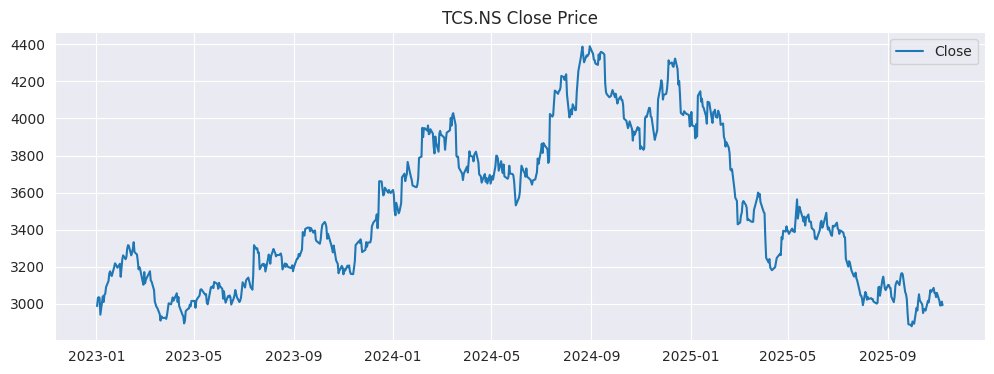

In [11]:
plt.figure(figsize=(12,4))
plt.plot(df['Close'], label='Close')
plt.title(f'{COMPANY} Close Price'); plt.legend(); plt.show()

Volume

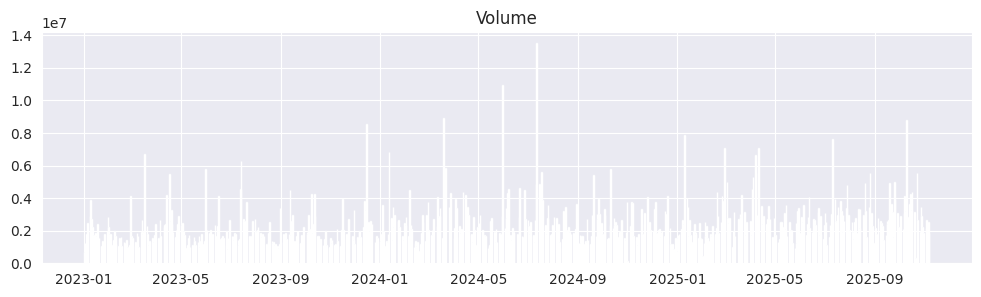

In [12]:
plt.figure(figsize=(12,3))
plt.bar(df.index, df['Volume']['TCS.NS'])
plt.title('Volume'); plt.show()

Returns distribution

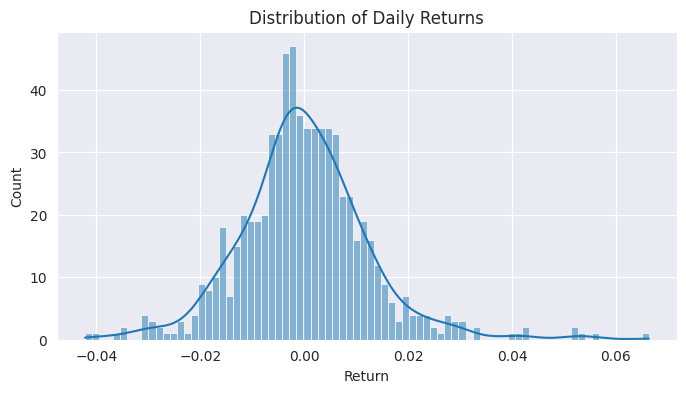

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df['Return'].dropna(), bins=80, kde=True)
plt.title('Distribution of Daily Returns'); plt.show()

Rolling volatility

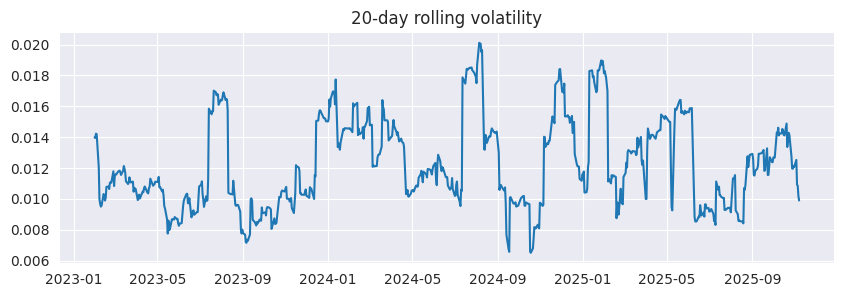

In [14]:
plt.figure(figsize=(10,3))
plt.plot(df['Return'].rolling(20).std(), label='20-day vol')
plt.title('20-day rolling volatility'); plt.show()

**Feature engineering (indicators)**

In [15]:
def sma(series, window): return series.rolling(window).mean()
def ema(series, span): return series.ewm(span=span, adjust=False).mean()


In [16]:
def rsi(series, window=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    ma_up = up.rolling(window=window, min_periods=window).mean()
    ma_down = down.rolling(window=window, min_periods=window).mean()
    rs = ma_up / ma_down
    return 100 - (100 / (1 + rs))

In [17]:
def macd(series, span_short=12, span_long=26, span_signal=9):
    ema_short = ema(series, span_short)
    ema_long = ema(series, span_long)
    macd_line = ema_short - ema_long
    signal = macd_line.ewm(span=span_signal, adjust=False).mean()
    hist = macd_line - signal
    return macd_line, signal, hist

In [18]:

def bollinger(series, window=20, n_std=2):
    sma_ = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper = sma_ + n_std * std
    lower = sma_ - n_std * std
    return upper, lower

In [19]:
def volatility(series, window=10):
    return series.pct_change().rolling(window).std()

In [20]:
data = df.copy()
close = data['Close']

In [21]:
data['SMA_5'] = sma(close,5)
data['SMA_10'] = sma(close,10)
data['SMA_20'] = sma(close,20)
data['EMA_12'] = ema(close,12)
data['EMA_26'] = ema(close,26)

data['MACD_line'], data['MACD_signal'], data['MACD_hist'] = macd(close)
data['RSI_14'] = rsi(close, 14)
data['BB_upper'], data['BB_lower'] = bollinger(close, 20, 2)
data['BB_width'] = data['BB_upper'] - data['BB_lower']
data['Volatility_10'] = volatility(close, 10)

In [22]:
for lag in range(1,6):
    data[f'Return_lag_{lag}'] = data['Return'].shift(lag)

data['Volume_change'] = data['Volume'].pct_change()
data['Volume_change'].replace([np.inf, -np.inf], np.nan, inplace=True)
data['Volume_sma_10'] = data['Volume'].rolling(10).mean()
data['Close_SMA_ratio_5_20'] = data['SMA_5'] / data['SMA_20']

bad = data.loc[data['Volume_change'].isin([np.inf, -np.inf])]
if len(bad):
    print("Rows where Volume_change was inf (before replace):")
    display(bad[['Volume','Volume_change']])

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()
print("Rows after feature engineering:", len(data))
data[[ 'Close','SMA_5','SMA_20','RSI_14','MACD_line','BB_upper','BB_lower']].tail()

Rows where Volume_change was inf (before replace):


/tmp/ipython-input-192121715.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Volume_change'].replace([np.inf, -np.inf], np.nan, inplace=True)


Price,Volume,Volume_change
Ticker,TCS.NS,
Date,,
2025-03-19,3051244,inf
2025-11-06,2542721,inf


Rows after feature engineering: 683


Price,Close,SMA_5,SMA_20,RSI_14,MACD_line,BB_upper,BB_lower
Ticker,TCS.NS,,,,,,
Date,,,,,,,
2025-10-31,3058.000000,3058.739990,3010.720520,56.211590,9.881833,3111.712672,2909.728368
2025-11-03,3016.800049,3045.120020,3017.004675,52.969219,7.586237,3100.845820,2933.163530
2025-11-04,2990.199951,3031.580029,3017.649890,56.202599,3.579295,3100.395810,2934.903970
2025-11-05,2990.199951,3018.100000,3019.027380,53.298823,0.399163,3098.781334,2939.273427
2025-11-07,2991.800049,2999.979980,3015.848645,54.358088,-2.626121,3095.094692,2936.602598


Lets Decide the Target :


In [23]:
# Target: next-day direction (1 = Up, 0 = Down)

In [24]:
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data = data.dropna()  # final cleanup (last row loses target)
print("Target distribution:")
display(data['Target'].value_counts(), data['Target'].value_counts(normalize=True))


Target distribution:


,count
Target,
0,363
1,320


,proportion
Target,
0,0.531479
1,0.468521


In [25]:
print("Mean RSI when next-day Up / Down")
display(data.groupby('Target')['RSI_14'].mean())

Mean RSI when next-day Up / Down


,RSI_14
Target,
0,49.238574
1,49.306275


Scatter/overlay example (last 250 days)

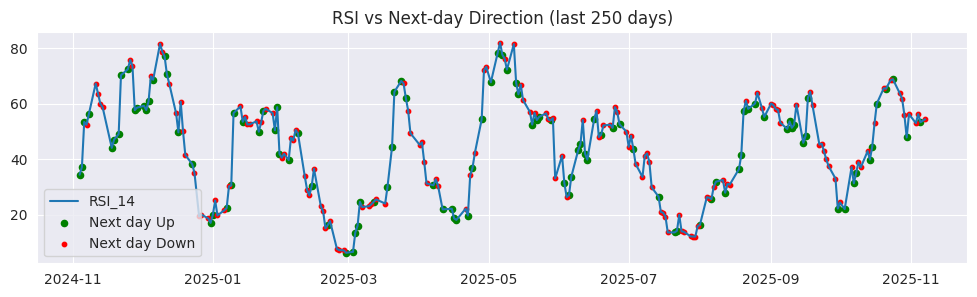

In [26]:
sample = data[-250:]
plt.figure(figsize=(12,3))
plt.plot(sample.index, sample['RSI_14'], label='RSI_14')
plt.scatter(sample.index[sample['Target']==1], sample['RSI_14'][sample['Target']==1], c='g', s=20, label='Next day Up')
plt.scatter(sample.index[sample['Target']==0], sample['RSI_14'][sample['Target']==0], c='r', s=10, label='Next day Down')
plt.legend(); plt.title('RSI vs Next-day Direction (last 250 days)'); plt.show()


Time-based train/test split

In [27]:
train_frac = 0.8
n = len(data)
split_idx = int(n * train_frac)
train = data.iloc[:split_idx].copy()
test  = data.iloc[split_idx:].copy()
print("Train rows:", len(train), "Test rows:", len(test))

Train rows: 546 Test rows: 137


Lets select the features to use

In [28]:
FEATURES = [
    'SMA_5','SMA_10','SMA_20','EMA_12','EMA_26',
    'MACD_line','MACD_signal','MACD_hist','RSI_14',
    'BB_upper','BB_lower','BB_width',
    'Volatility_10','Close_SMA_ratio_5_20',
    'Return_lag_1','Return_lag_2','Return_lag_3',
    'Volume_change','Volume_sma_10'
]
FEATURES = [f for f in FEATURES if f in data.columns]
X_train = train[FEATURES]; y_train = train['Target']
X_test  = test[FEATURES];  y_test  = test['Target']
print("Num features:", len(FEATURES)); print(FEATURES)

Num features: 19
['SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD_line', 'MACD_signal', 'MACD_hist', 'RSI_14', 'BB_upper', 'BB_lower', 'BB_width', 'Volatility_10', 'Close_SMA_ratio_5_20', 'Return_lag_1', 'Return_lag_2', 'Return_lag_3', 'Volume_change', 'Volume_sma_10']


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Model traingn


In [30]:
models = {
    'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

In [31]:
results = {}
for name, model in models.items():
    print("Training", name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)
    except Exception:
        y_proba = None
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    results[name] = {'model': model, 'metrics': metrics}
    print(name, "accuracy:", metrics['accuracy'])

Training LogisticRegression
LogisticRegression accuracy: 0.43795620437956206
Training RandomForest
RandomForest accuracy: 0.583941605839416
Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:35:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost accuracy: 0.5401459854014599


⁠Some *inf* values appeared in the Volume_change column due to division by very small or zero denominators. The helper code below identifies the affected rows ,I have replaced those infinite values with NaN to ensure clean data for modeling.


In [32]:


# def diagnostics(X, name="X"):
#     print(f"Diagnostics for {name}:")
#     print("shape:", X.shape)
#     print("any NaN:", X.isna().any().any())
#     print("columns with NaN:\n", X.isna().sum()[X.isna().sum()>0])
#     inf_mask = np.isinf(X)
#     if inf_mask.any().any():
#         print("columns with +inf/-inf:\n", pd.DataFrame(inf_mask, columns=X.columns).any().loc[lambda s: s].index.tolist())
#         bad_rows = X[~np.isfinite(X).all(axis=1)]
#         print("Number of bad rows:", len(bad_rows))
#         display(bad_rows.head(10))
#     else:
#         print("No +inf/-inf found.")
#     print("max absolute value per column (for spotting huge values):")
#     print(X.abs().max().sort_values(ascending=False).head(10))

# #  diagnostics on train and test
# diagnostics(X_train, "X_train")
# diagnostics(X_test, "X_test")

Model evaluation & visualizations

LogisticRegression 
Accuracy: 0.438
Precision: 0.3778
Recall: 0.6182
F1: 0.469


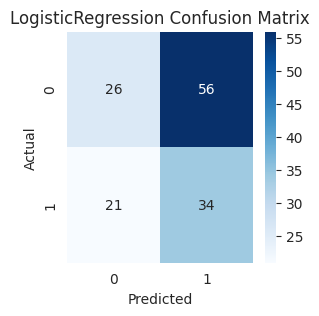

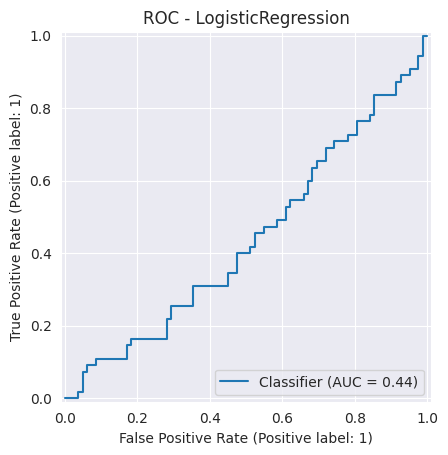

RandomForest 
Accuracy: 0.5839
Precision: 0.48
Recall: 0.4364
F1: 0.4571


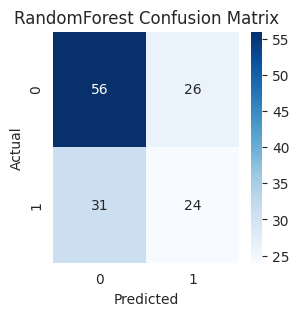

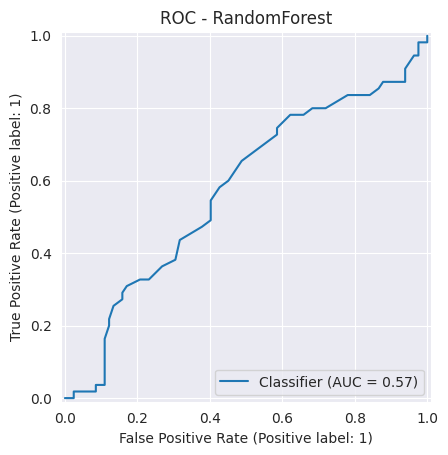

XGBoost 
Accuracy: 0.5401
Precision: 0.4412
Recall: 0.5455
F1: 0.4878


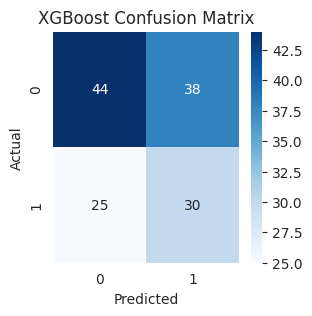

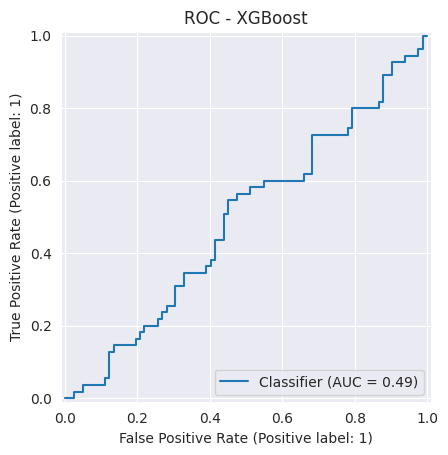

In [36]:
from sklearn.metrics import RocCurveDisplay

for name, res in results.items():
    m = res['metrics']
    print(f"{name} ")
    print("Accuracy:", round(m['accuracy'],4))
    print("Precision:", round(m['precision'],4))
    print("Recall:", round(m['recall'],4))
    print("F1:", round(m['f1'],4))
    # Confusion matrix
    cm = m['confusion_matrix']
    plt.figure(figsize=(3,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()
    # ROC (if proba available)
    if m['y_proba'] is not None:
        try:
            RocCurveDisplay.from_predictions(y_test, m['y_proba'][:,1])
            plt.title(f'ROC - {name}'); plt.show()
        except Exception as e:
            print("ROC error:", e)

Saving Model to use in streamlit app .
The code in below cell saves model to output folder

In [37]:
import joblib
best = max(results.keys(), key=lambda n: results[n]['metrics']['accuracy'])
print("Best model:", best)

joblib.dump(results[best]['model'], f"outputs/models/{best}_{COMPANY.replace('.','_')}.joblib")
print("Saved model to outputs/models/")


cm = results[best]['metrics']['confusion_matrix']
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title(f'{best} Confusion Matrix')
plt.savefig(f"outputs/figures/{best}_confusion.png", bbox_inches='tight'); plt.close()
print("Saved confusion matrix figure to outputs/figures/")


Best model: RandomForest
Saved model to outputs/models/
Saved confusion matrix figure to outputs/figures/


Feature importance / coefficients (interpretability)


-- LogisticRegression


,0
SMA_10,0.269477
SMA_5,-0.156266
Volume_change,0.134808
MACD_hist,-0.117393
BB_lower,-0.100723
SMA_20,-0.086043
Volume_sma_10,0.084054
BB_upper,-0.071493
Volatility_10,0.067789
Return_lag_3,-0.067086


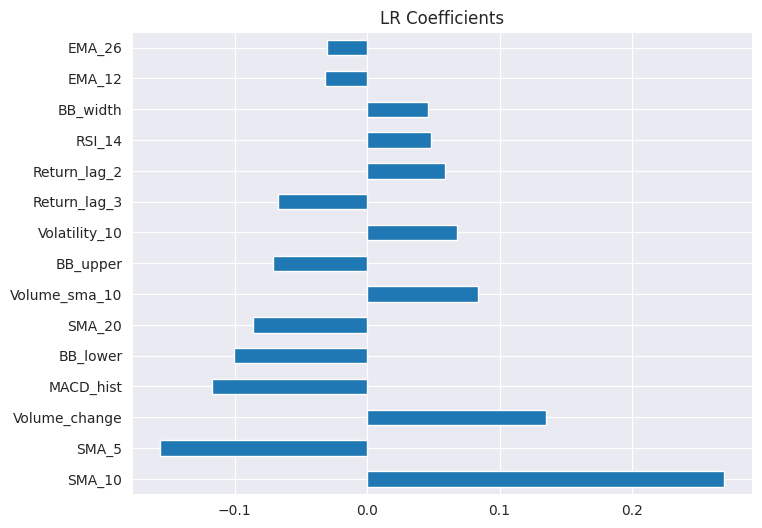


-- RandomForest


,0
Return_lag_1,0.066175
Return_lag_3,0.064174
Return_lag_2,0.062542
Volume_change,0.062426
Volume_sma_10,0.060716
MACD_hist,0.059965
RSI_14,0.059690
Volatility_10,0.058969
Close_SMA_ratio_5_20,0.054946
MACD_signal,0.052498


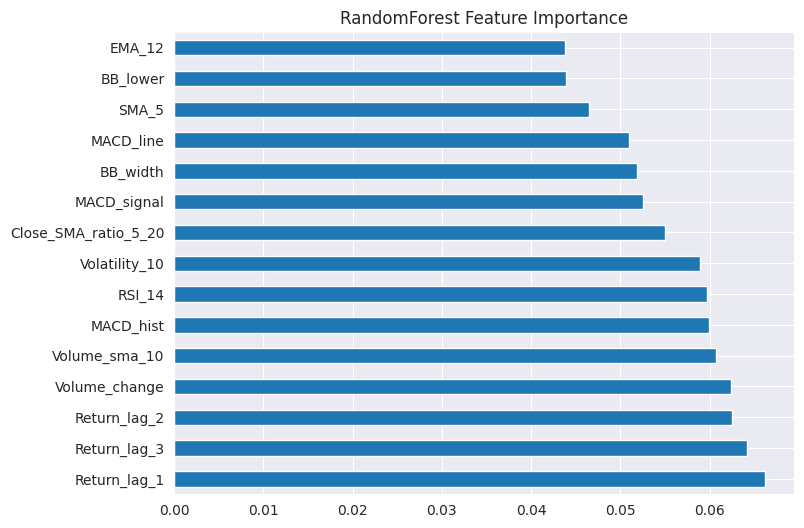


-- XGBoost


,0
SMA_5,0.069538
EMA_12,0.062898
EMA_26,0.058439
BB_lower,0.058017
MACD_hist,0.057578
BB_upper,0.057021
Volume_sma_10,0.055304
Volatility_10,0.052721
Return_lag_2,0.052221
MACD_line,0.051726


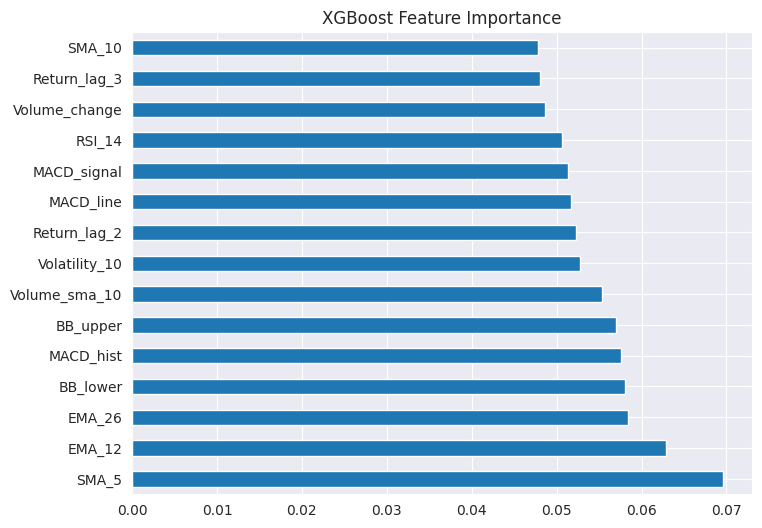

In [38]:
for name, res in results.items():
    model = res['model']
    print("\n--", name)
    if hasattr(model, 'feature_importances_'):
        fi = model.feature_importances_
        fi_series = pd.Series(fi, index=FEATURES).sort_values(ascending=False)
        display(fi_series.head(15))
        fi_series.head(15).plot(kind='barh', figsize=(8,6)); plt.title(f'{name} Feature Importance'); plt.show()
    elif name == 'LogisticRegression':
        coefs = model.named_steps['clf'].coef_[0]
        coef_series = pd.Series(coefs, index=FEATURES).sort_values(key=abs, ascending=False)
        display(coef_series.head(15))
        coef_series.head(15).plot(kind='barh', figsize=(8,6)); plt.title('LR Coefficients'); plt.show()


Actual vs predicted signals on price timeline

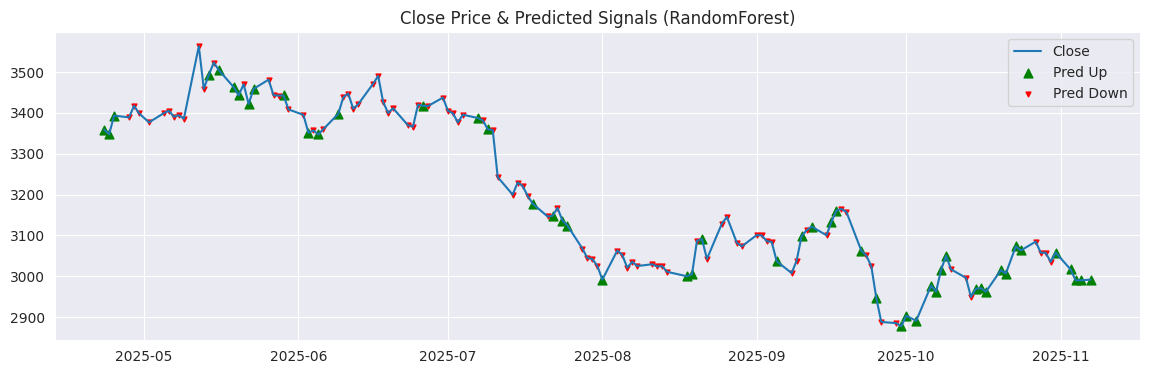

<Figure size 640x480 with 0 Axes>

In [39]:
test2 = test.copy()
best = max(results.keys(), key=lambda n: results[n]['metrics']['accuracy'])
test2['Pred_'+best] = results[best]['metrics']['y_pred']
plt.figure(figsize=(14,4))
plt.plot(test2.index, test2['Close'], label='Close')
plt.scatter(test2.index[test2['Pred_'+best]==1], test2.loc[test2['Pred_'+best]==1,'Close'], marker='^', c='g', s=40, label='Pred Up')
plt.scatter(test2.index[test2['Pred_'+best]==0], test2.loc[test2['Pred_'+best]==0,'Close'], marker='v', c='r', s=12, label='Pred Down')
plt.legend(); plt.title(f'Close Price & Predicted Signals ({best})'); plt.show()

plt.savefig(f'outputs/figures/actual_vs_pred_{best}.png', bbox_inches='tight')


Below is the code for streamlit UI which i have run only on my local device .
Its easy to use .
Just install
"   pip install streamlit yfinance pandas numpy matplotlib seaborn joblib scikit-learn xgboost
  streamlit "
Make a folder in your virtual environment name as outputs/models
Put the above model in it ,which we have downloaded (it is a .joblib type of file)


**Streamlit UI APPCODE**

streamlit run app_streamlit.py

use this simple command to run the app on local device


In [ ]:
# """
# Streamlit app to predict next-day Up (1) or Down (0) for a chosen NSE ticker.

# Usage:
#   pip install streamlit yfinance pandas numpy matplotlib seaborn joblib scikit-learn xgboost
#   streamlit run app_streamlit_simple.py

# Put your model files inside: outputs/models/
# Example model filenames:
#   XGBoost_TCS_NS.joblib
#   RandomForest_TCS_NS.joblib
#   LogisticRegression_TCS_NS.joblib
# """

# import streamlit as st
# import pandas as pd
# import numpy as np
# import yfinance as yf
# import joblib
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os
# from datetime import date

# sns.set_style("whitegrid")


# def sma(s, window): return s.rolling(window).mean()
# def ema(s, span): return s.ewm(span=span, adjust=False).mean()
# def rsi(s, window=14):
#     d = s.diff()
#     up = d.clip(lower=0); down = -1 * d.clip(upper=0)
#     ma_up = up.rolling(window).mean(); ma_down = down.rolling(window).mean()
#     rs = ma_up / ma_down
#     return 100 - (100 / (1 + rs))
# def macd(s, short=12, long=26, signal=9):
#     es = ema(s, short); el = ema(s, long)
#     macd_line = es - el
#     macd_signal = macd_line.ewm(span=signal, adjust=False).mean()
#     macd_hist = macd_line - macd_signal
#     return macd_line, macd_signal, macd_hist
# def bollinger(s, window=20, n_std=2):
#     m = s.rolling(window).mean(); sd = s.rolling(window).std()
#     return m + n_std*sd, m - n_std*sd
# def volatility(s, window=10):
#     return s.pct_change().rolling(window).std()

# # #Features list
# FEATURES = [
#     'SMA_5','SMA_10','SMA_20','EMA_12','EMA_26',
#     'MACD_line','MACD_signal','MACD_hist','RSI_14',
#     'BB_upper','BB_lower','BB_width',
#     'Volatility_10','Close_SMA_ratio_5_20',
#     'Return_lag_1','Return_lag_2','Return_lag_3',
#     'Volume_change','Volume_sma_10'
# ]


# def build_features(df):
#     data = df.copy()
#     close = data['Close']
#     data['Return'] = close.pct_change()
#     data['SMA_5'] = sma(close, 5); data['SMA_10'] = sma(close, 10); data['SMA_20'] = sma(close,20)
#     data['EMA_12'] = ema(close, 12); data['EMA_26'] = ema(close, 26)
#     data['MACD_line'], data['MACD_signal'], data['MACD_hist'] = macd(close)
#     data['RSI_14'] = rsi(close, 14)
#     data['BB_upper'], data['BB_lower'] = bollinger(close, 20, 2)
#     data['BB_width'] = data['BB_upper'] - data['BB_lower']
#     data['Volatility_10'] = volatility(close, 10)
#     for lag in range(1,6):
#         data[f'Return_lag_{lag}'] = data['Return'].shift(lag)
#     data['Volume_change'] = data['Volume'].pct_change()
#     data['Volume_sma_10'] = data['Volume'].rolling(10).mean()
#     data['Close_SMA_ratio_5_20'] = data['SMA_5'] / data['SMA_20']
#     # target not needed for prediction, but training created it as next-day indicator
#     data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
#     data = data.dropna()
#     return data

# def find_model_for_ticker(ticker, models_dir="outputs/models"):

#     key = ticker.replace('.', '_')
#     if not os.path.exists(models_dir):
#         return None
#     all_files = os.listdir(models_dir)
#     candidates = [f for f in all_files if key in f and f.lower().endswith('.joblib')]
#     if not candidates:
#         return None
#     # ordering priority
#     priority = ['xgboost', 'randomforest', 'logistic']
#     candidates_lower = [(f, f.lower()) for f in candidates]
#     for p in priority:
#         for orig, low in candidates_lower:
#             if p in low:
#                 return os.path.join(models_dir, orig)
#     return os.path.join(models_dir, candidates[0])

# ## UI for app
# st.set_page_config(page_title="Next-day Up/Down Predictor", layout="centered")
# st.title("AARTHIC")

# st.markdown("Next-day Up/Down Predictor")

# with st.form("main_form"):
#     ticker = st.text_input("COMPANY (NSE)", value="TCS.NS").strip()
#     start_date = st.date_input("History start date", value=date(2023,1,1))
#     days_show = st.slider("Show last N days", min_value=60, max_value=365, value=180)
#     submit = st.form_submit_button("Run prediction")

# if not submit:
#     st.info("Enter inputs and click 'Run prediction' to start.")
#     st.stop()

# # fetch data
# try:
#     df = yf.download(ticker, start=str(start_date), progress=False)
# except Exception as e:
#     st.error(f"Failed to fetch data for {ticker}: {e}")
#     st.stop()

# if df is None or df.empty:
#     st.error("No data returned. Check ticker and start date.")
#     st.stop()

# df = df.sort_index().ffill().dropna(how='all')
# data = build_features(df)
# if data.empty:
#     st.error("Not enough history to compute indicators. Try an earlier start date.")
#     st.stop()

# # auto-find model
# model_path = find_model_for_ticker(ticker, models_dir="outputs/models")
# if model_path is None:
#     st.error(f"No .joblib model found for ticker '{ticker}' in outputs/models/. Place your model file there (e.g. XGBoost_{ticker.replace('.', '_')}.joblib).")
#     st.stop()

# try:
#     model = joblib.load(model_path)
# except Exception as e:
#     st.error(f"Failed to load model at {model_path}: {e}")
#     st.stop()

# st.success(f"Loaded model: `{os.path.basename(model_path)}`")

# # ensure required features present
# missing = [f for f in FEATURES if f not in data.columns]
# if missing:
#     st.error(f"Missing features after preprocessing: {missing}")
#     st.stop()

# X = data[FEATURES].copy()
# X_latest = X.iloc[-1:].fillna(method='ffill').fillna(0)

# # predict
# try:
#     pred = model.predict(X_latest)
#     prob = None
#     if hasattr(model, "predict_proba"):
#         try:
#             prob = model.predict_proba(X_latest)[:,1]
#         except Exception:
#             prob = None
# except Exception as e:
#     st.error(f"Prediction failed: {e}")
#     st.stop()

# pred_label = int(pred[0])
# pred_text = "Up (1)" if pred_label == 1 else "Down (0)"

# # Display results: clear, assignment-friendly 0/1 and Up/Down
# st.subheader("Prediction")
# cola, colb = st.columns([1,2])
# with cola:
#     st.metric("Next-day direction (0/1)", str(pred_label))
# with colb:
#     st.write(f"**Interpreted:** {pred_text}")
#     if prob is not None:
#         st.write(f"**Probability of Up:** {prob[0]:.3f}")

# # show a compact price + indicator plot
# st.subheader("Recent price & indicators")
# plot_n = min(days_show, len(data))
# plot_df = data.tail(plot_n)

# fig, axes = plt.subplots(3,1, figsize=(9,8), sharex=True)
# axes[0].plot(plot_df.index, plot_df['Close'], label='Close', linewidth=1)
# axes[0].plot(plot_df.index, plot_df['SMA_5'], label='SMA_5', linewidth=0.9, alpha=0.8)
# axes[0].plot(plot_df.index, plot_df['SMA_20'], label='SMA_20', linewidth=0.9, alpha=0.8)
# axes[0].legend(loc='upper left', fontsize='small')
# axes[0].set_ylabel("Price")

# axes[1].plot(plot_df.index, plot_df['RSI_14'], label='RSI_14')
# axes[1].axhline(70, color='red', linewidth=0.6, linestyle='--')
# axes[1].axhline(30, color='green', linewidth=0.6, linestyle='--')
# axes[1].set_ylabel("RSI")

# axes[2].plot(plot_df.index, plot_df['MACD_line'], label='MACD_line', linewidth=0.9)
# axes[2].plot(plot_df.index, plot_df['MACD_signal'], label='MACD_signal', linewidth=0.9, alpha=0.8)
# axes[2].bar(plot_df.index, plot_df['MACD_hist'], label='MACD_hist', alpha=0.6)
# axes[2].set_ylabel("MACD")

# plt.tight_layout()
# st.pyplot(fig)

# # show top feature importances or coefficients if available (compact)
# st.subheader("Top predictive features (if available)")
# try:
#     model_for_imp = model
#     if hasattr(model, 'named_steps'):
#         # pipeline: try to get classifier step
#         named = model.named_steps
#         if 'clf' in named:
#             model_for_imp = named['clf']
#         else:
#             # fallback: last step
#             model_for_imp = list(named.values())[-1]
#     if hasattr(model_for_imp, 'feature_importances_'):
#         fi = pd.Series(model_for_imp.feature_importances_, index=FEATURES).sort_values(ascending=False).head(10)
#         st.table(fi.rename("importance").to_frame())
#     elif hasattr(model_for_imp, 'coef_'):
#         coef = model_for_imp.coef_
#         if coef.ndim == 2: coef = coef[0]
#         coef_s = pd.Series(coef, index=FEATURES).abs().sort_values(ascending=False).head(10)
#         st.table(coef_s.rename("abs_coef").to_frame())
#     else:
#         st.write("Model does not expose feature importances or coefficients.")
# except Exception:
#     st.write("Could not compute feature importance for this model.")

# # small footer
# st.markdown("---")
# st.caption("Simple app: predicts next-day Up (1) / Down (0). Make sure the model was trained with the same features.")
